# Assignment 2: Housing Affordability and Unemployment Hotspots in the UK: A Spatial Inequality Analysis

In [24]:
import os
import sys
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import panel as pn
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from IPython.display import HTML, display
from bokeh.plotting import figure
from bokeh.resources import INLINE
from bokeh.palettes import Viridis256, Plasma256, Magma256, Inferno256
from bokeh.models import (
    ColumnDataSource, 
    GeoJSONDataSource, 
    LinearColorMapper, 
    ColorBar, 
    BasicTicker, 
    HoverTool, 
    WMTSTileSource, 
    CustomJSTickFormatter,
    NumeralTickFormatter,
    Range1d,
    Select,
    Slider,
    Div
)
from IPython.display import IFrame
import base64
import matplotlib
matplotlib.use('Agg')
import io

from bokeh.layouts import column, row, layout as bk_layout
from bokeh.embed import file_html
from bokeh.models.widgets import Select as BkSelect

## Introduction, Context, and Short literature review on the problem (~ 250 words)

Two of the most pressing dimensions of spatial economic inequality in the United Kingdom are housing affordability and labour market conditions. Over the last two decades, house prices in many English regions have grown much faster than earnings, gradually cutting away at the prospects of home ownership and shifting financial pressure to lower-income households (ONS, 2024). At the same time, unemployment continues to be unevenly distributed across the country, reflecting persistent structural differences rooted in deindustrialisation, uneven investment and the long-standing economic divergence between the north and south of England (Beatty and Fothergill, 2016; McCann, 2016).


The most widely used measure of housing affordability is the price-to-income ratio, which measures the extent to which local property values exceed local earnings capacity. London and the South East are consistently identified as areas of acute affordability pressure, driven by high housing demand in economically productive areas with high wages but severely constrained housing supply (Szumilo, 2019; Barker, 2004). A structural driver of deterioration in affordability at the national level has been identified as a housing undersupply relative to demand, with especially acute consequences for younger and lower-income households (Barker, 2004; Tunstall et al., 2013). By contrast, regional labour market studies identify persistent unemployment hotspots in former industrial areas where limited economic diversification continues to constrain job creation and wage growth. (Beatty and Fothergill, 2016). Python-based geographic data science methods provide an established framework for conducting this kind of multi-variable spatial analysis at local authority level (Rey et al., 2020).

Despite these parallel literatures, there is a relative lack of studies on the combined spatial dynamics of both phenomena at local authority level. This is a big gap: it is not yet clear whether weak labour markets always go with more affordable housing because there is suppressed demand, or whether different types of economic disadvantage tend to cluster together in the same places. This project addresses this gap by bringing together data on house prices, income and unemployment across English local authorities to conduct a geospatial analysis of affordability and labour market conditions, thereby providing empirical insight into the geography of regional inequality.

In [2]:
# LOAD ALL DATA 
gdf    = gpd.read_file("boundaries-local-authorities-2025-england.geojson")
income = pd.read_excel("PROV - Home Geography Table 8.7a   Annual pay - Gross 2025.xlsx", 
                       sheet_name="All", skiprows=4, engine="openpyxl")
unemp  = pd.read_excel("modelbasedunemploymentdataaugust2022.xls", 
                       sheet_name="LA,UA Rates", skiprows=5, engine="xlrd")

# CLEAN INCOME 
income_clean = income.rename(columns={'Code': 'area_code', 'Median': 'median_income'}).copy()
income_clean['median_income'] = pd.to_numeric(income_clean['median_income'].replace('x', np.nan), errors='coerce')
income_clean['area_code'] = income_clean['area_code'].astype(str).str.strip()

# CLEAN UNEMPLOYMENT
unemp_clean = unemp.iloc[:, [1, 234]].copy()
unemp_clean.columns = ['area_code', 'unemployment_rate']
unemp_clean['unemployment_rate'] = pd.to_numeric(unemp_clean['unemployment_rate'].replace(':', np.nan), errors='coerce')
unemp_clean['area_code'] = unemp_clean['area_code'].astype(str).str.strip()

# LOAD & CLEAN HOUSE PRICES 
hp_raw = pd.read_csv("UK-HPI-full-file-2024-01.csv",
                     usecols=['Date', 'RegionName', 'AreaCode', 'AveragePrice'])
hp_raw['Date'] = pd.to_datetime(hp_raw['Date'], dayfirst=True)
hp_raw['year'] = hp_raw['Date'].dt.year

# England LAs only, limit to 2010–2023
hp_raw = hp_raw[hp_raw['AreaCode'].str.startswith('E', na=False)]
hp_raw = hp_raw[hp_raw['year'].between(2010, 2023)]
hp_raw['AveragePrice'] = pd.to_numeric(hp_raw['AveragePrice'], errors='coerce')

# Aggregate monthly → annual average per LA
house_final = (
    hp_raw.groupby(['AreaCode', 'year'], as_index=False)
    .agg(median_house_price=('AveragePrice', 'mean'))
)

available_years = sorted(house_final['year'].dropna().unique(), reverse=True)

# MASTER MERGE 
gdf['local_authority_code'] = gdf['local_authority_code'].astype(str).str.strip()
gdf = gdf.merge(income_clean[['area_code', 'median_income']],    
                left_on='local_authority_code', right_on='area_code', how='left')
gdf = gdf.merge(unemp_clean[['area_code', 'unemployment_rate']], 
                on='area_code', how='left')

final_gdf = gdf.to_crs(epsg=3857)

# ADD HOUSE PRICES & AFFORDABILITY RATIO FOR STATIC MAPS
selected_year = 2023  # change to any year between 2010–2023

hp_year = house_final[house_final['year'] == selected_year][['AreaCode', 'median_house_price']]
final_gdf = final_gdf.merge(hp_year, left_on='local_authority_code', right_on='AreaCode', how='left')
final_gdf['affordability_ratio'] = final_gdf['median_house_price'] / final_gdf['median_income']

## Data Sources Presentation (~ 250 words)

The geospatial framework for this analysis is built using three datasets, chosen for their methodological fitness for the research problem and their origin as an authoritative national source.


Information on median gross annual pay at the level of local authority is taken from the ONS Annual Survey of Hours and Earnings (ASHE), table 8.7a (provisional release 2025). ASHE is the most robust and consistently produced source of earnings data at a sub-regional level for England. It is based on a 1% sample of employee records from HMRC’s Pay As You Earn system. It is preferred to alternatives like the Annual Population Survey (APS) as it uses employer-reported pay rather than self-reported estimates, which should reduce recall bias in the income variable.


Unemployment data comes from the ONS Model-Based Unemployment Estimates (August 2022 release) which uses a small-area estimation approach, combining Labour Force Survey data with claimant count data to produce rates at local authority level. This model-based approach is designed to cope with the small sample sizes which make direct LFS estimates unreliable at local authority level – an important consideration when comparing over 300 English authorities.


The house price data are from the HM Land Registry UK House Price Index full file (2024), combining all residential property transactions registered in England. The dashboard is characterised by a temporal dimension, with annual averages being calculated from monthly data for the period 2010–2023. We prefer this source to Zoopla or Rightmove asking-price indices because it is based on completed transaction prices rather than listed prices, and thus avoids the systematic upward bias introduced by vendor optimism.


The statistical geographies used in each data set are aligned using local authority boundaries from the ONS Open Geography Portal (2025 release).

It should be noted that the model-based unemployment estimates represent a single 2022 snapshot and do not vary with the year selector in the dashboard; a longitudinal unemployment series would be required to enable fully time-comparative analysis across all four metrics.

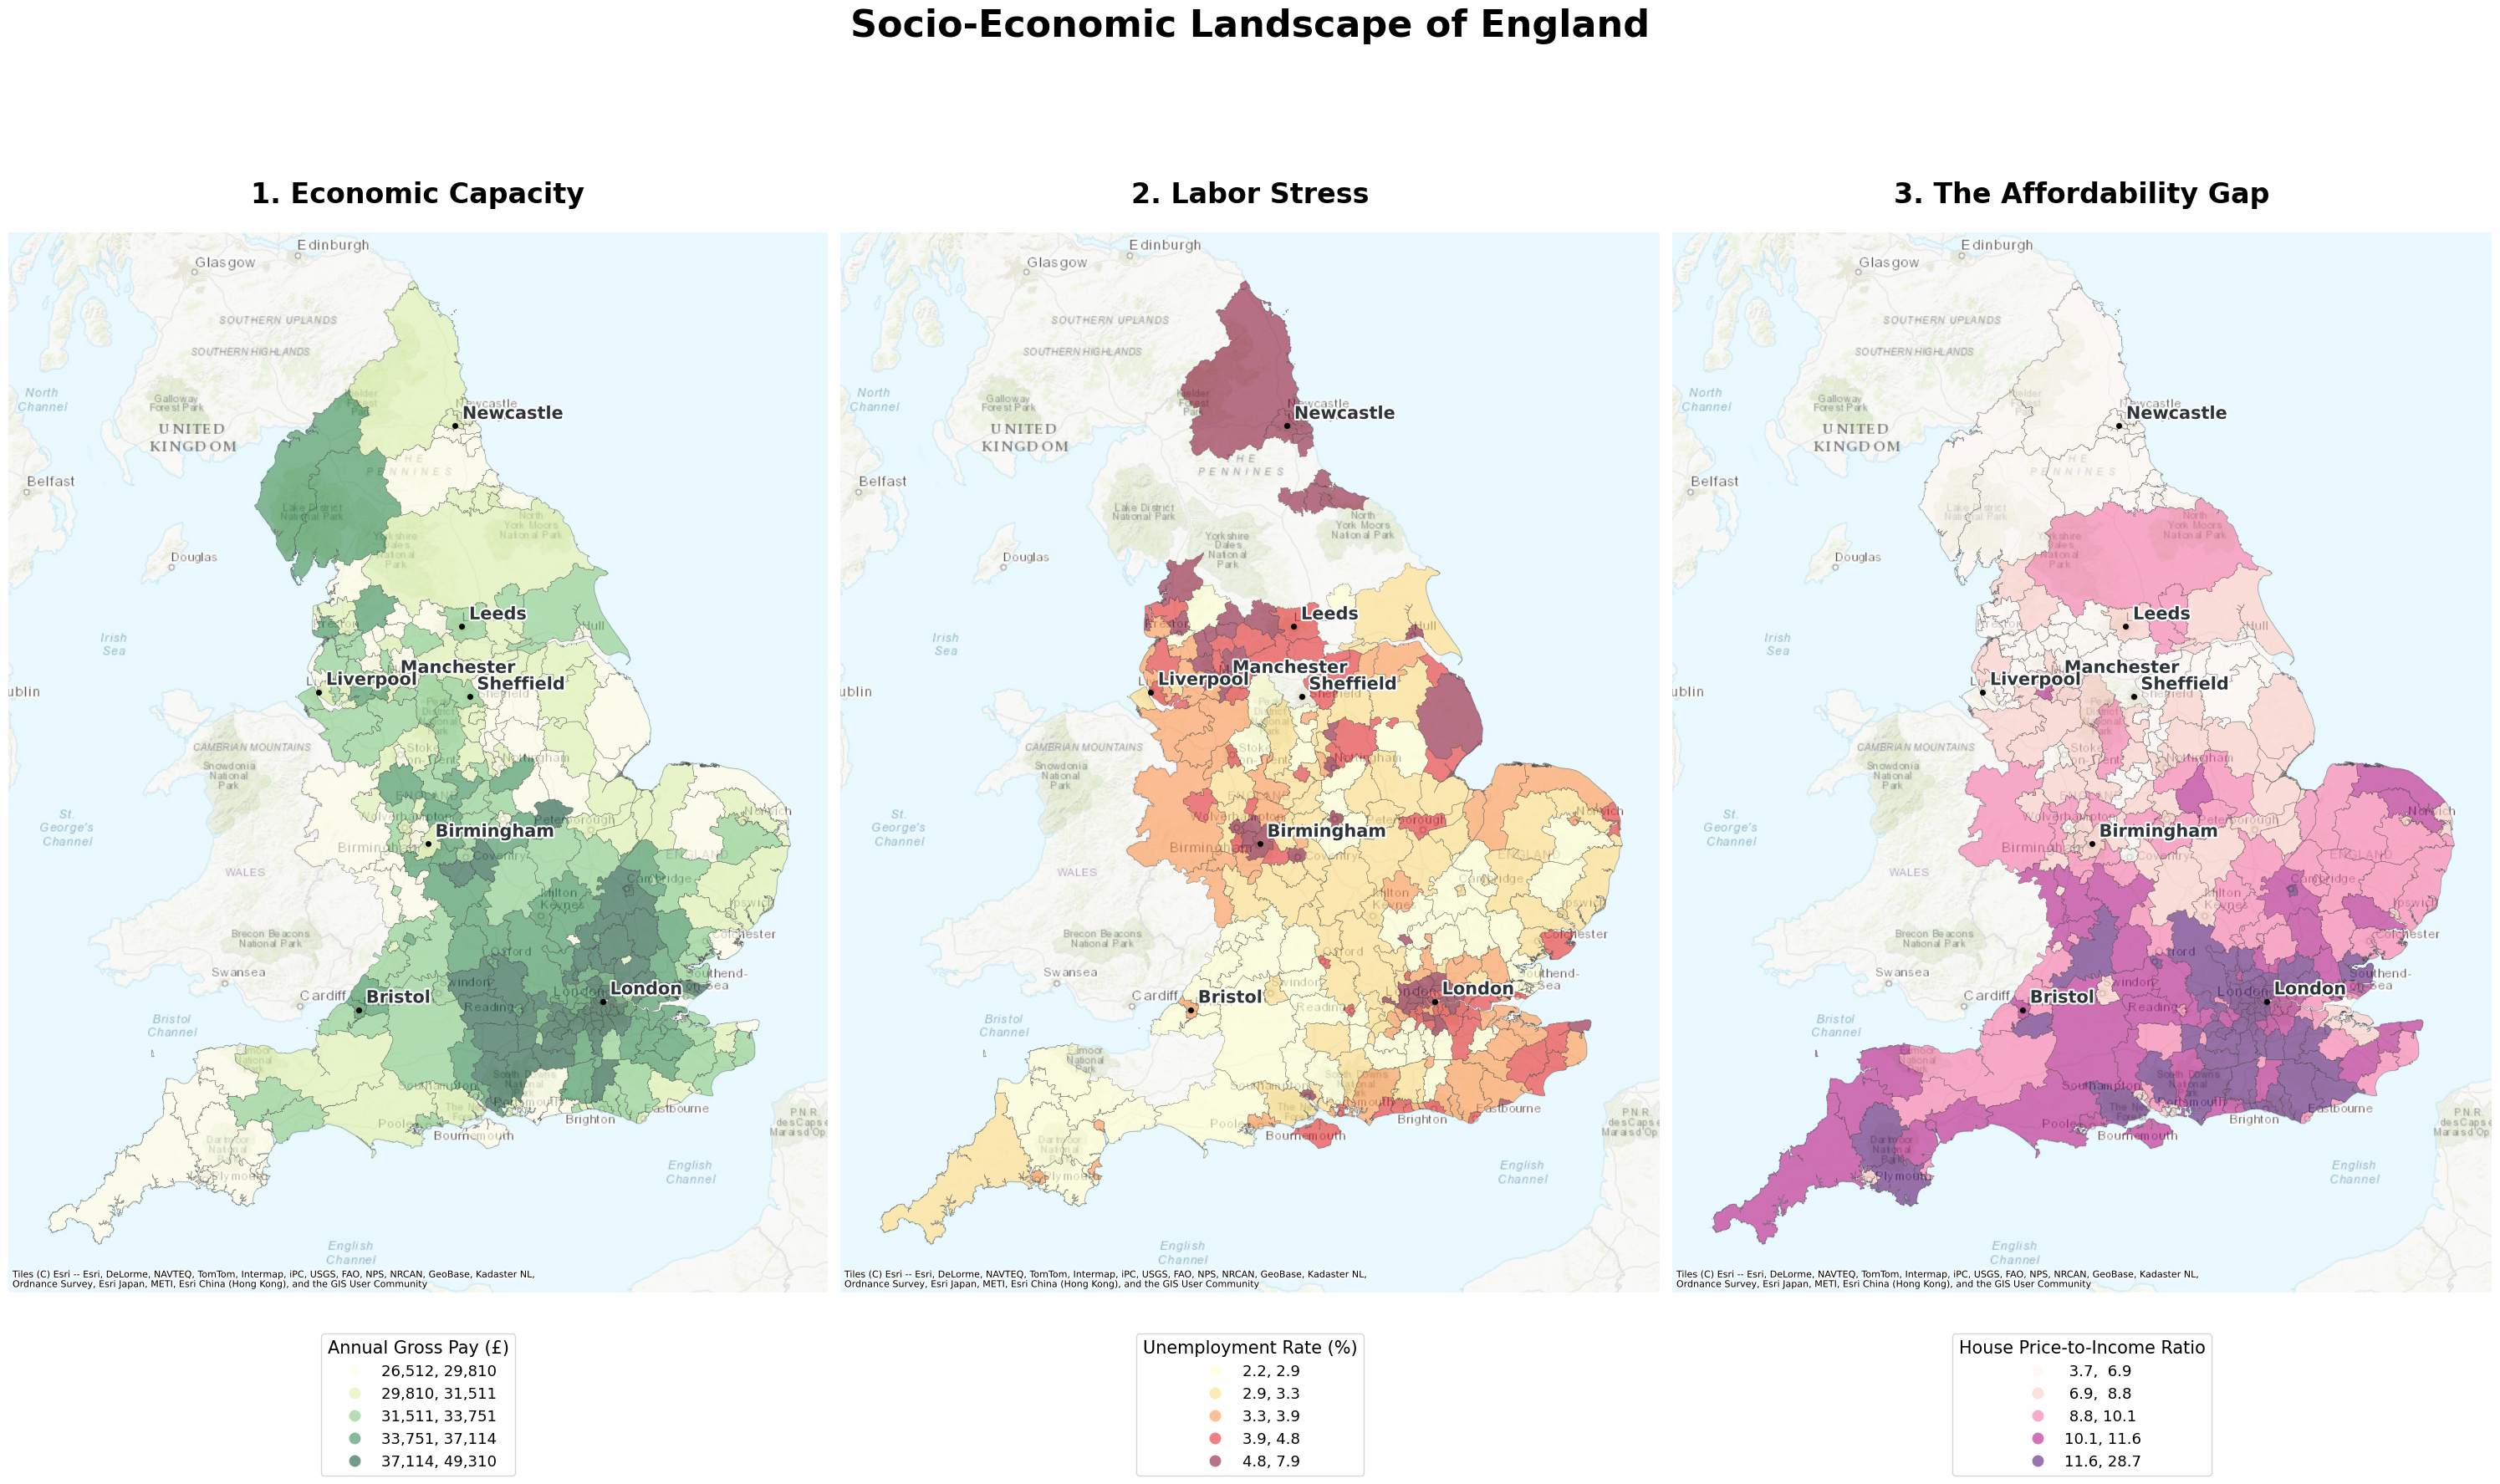

In [3]:
%matplotlib inline 

# DATA PREPARATION
final_gdf_3857 = final_gdf.to_crs(epsg=3857)

major_cities = {
    'London': (-0.1276, 51.5074), 'Birmingham': (-1.8904, 52.4862),
    'Manchester': (-2.2426, 53.4808), 'Leeds': (-1.5491, 53.8008),
    'Newcastle': (-1.6178, 54.9783), 'Bristol': (-2.5879, 51.4545),
    'Liverpool': (-2.9916, 53.4084), 'Sheffield': (-1.4701, 53.3811)
}

cols = ['median_income', 'unemployment_rate', 'affordability_ratio']
cmaps = ['YlGn', 'YlOrRd', 'RdPu']
titles = ['1. Economic Capacity', '2. Labor Stress', '3. The Affordability Gap']
legend_titles = ['Annual Gross Pay (£)', 'Unemployment Rate (%)', 'House Price-to-Income Ratio']

# PLOT EXECUTION
fig, axes = plt.subplots(1, 3, figsize=(30, 18), facecolor='white')

for i, ax in enumerate(axes):
    # --- DATA LAYER ---
    final_gdf_3857.plot(
        column=cols[i], 
        ax=ax, 
        cmap=cmaps[i], 
        scheme='Quantiles', 
        k=5,
        edgecolor='#4d4d4d', 
        linewidth=0.4,       
        alpha=0.55,
        legend=True, 
        legend_kwds={
            'title': legend_titles[i],
            'loc': 'lower center', 
            'bbox_to_anchor': (0.5, -0.18), 
            'ncol': 1,
            'fontsize': 13,
            'title_fontsize': 15,
            'frameon': True,
            'fmt': "{:,.0f}" if i == 0 else "{:.1f}"
        }
    )

    # HIGH DETAIL BASEMAP
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTopoMap, alpha=0.7, zoom=7)

    # CITY LABELS
    for city, (lon, lat) in major_cities.items():
        pt = gpd.GeoSeries(gpd.points_from_xy([lon], [lat]), crs="EPSG:4326").to_crs(epsg=3857)
        x, y = pt.geometry.x[0], pt.geometry.y[0]
        
        ax.plot(x, y, 'ko', markersize=4, zorder=10)
        # Using manual 8000m offset to prevent overlap with markers
        ax.text(x + 8000, y + 8000, city, fontsize=15, fontweight='bold', 
                color='#2d3436', zorder=11,
                path_effects=[pe.withStroke(linewidth=3, foreground="white")])

    ax.set_axis_off()
    ax.set_title(titles[i], fontsize=24, fontweight='bold', pad=25)

# ASSEMBLY & EXPORT

fig.suptitle('Socio-Economic Landscape of England', 
             fontsize=32, fontweight='black', y=0.95)

# We lower the 'top' value to 0.90 to create a dedicated gutter for the heading
plt.tight_layout(rect=[0, 0.03, 1, 0.90])

# This ensures the final PNG/PDF has a clean white border around the heading
plt.savefig('socio_economic_analysis_v2.png', dpi=150, bbox_inches='tight', pad_inches=0.5)

plt.show()

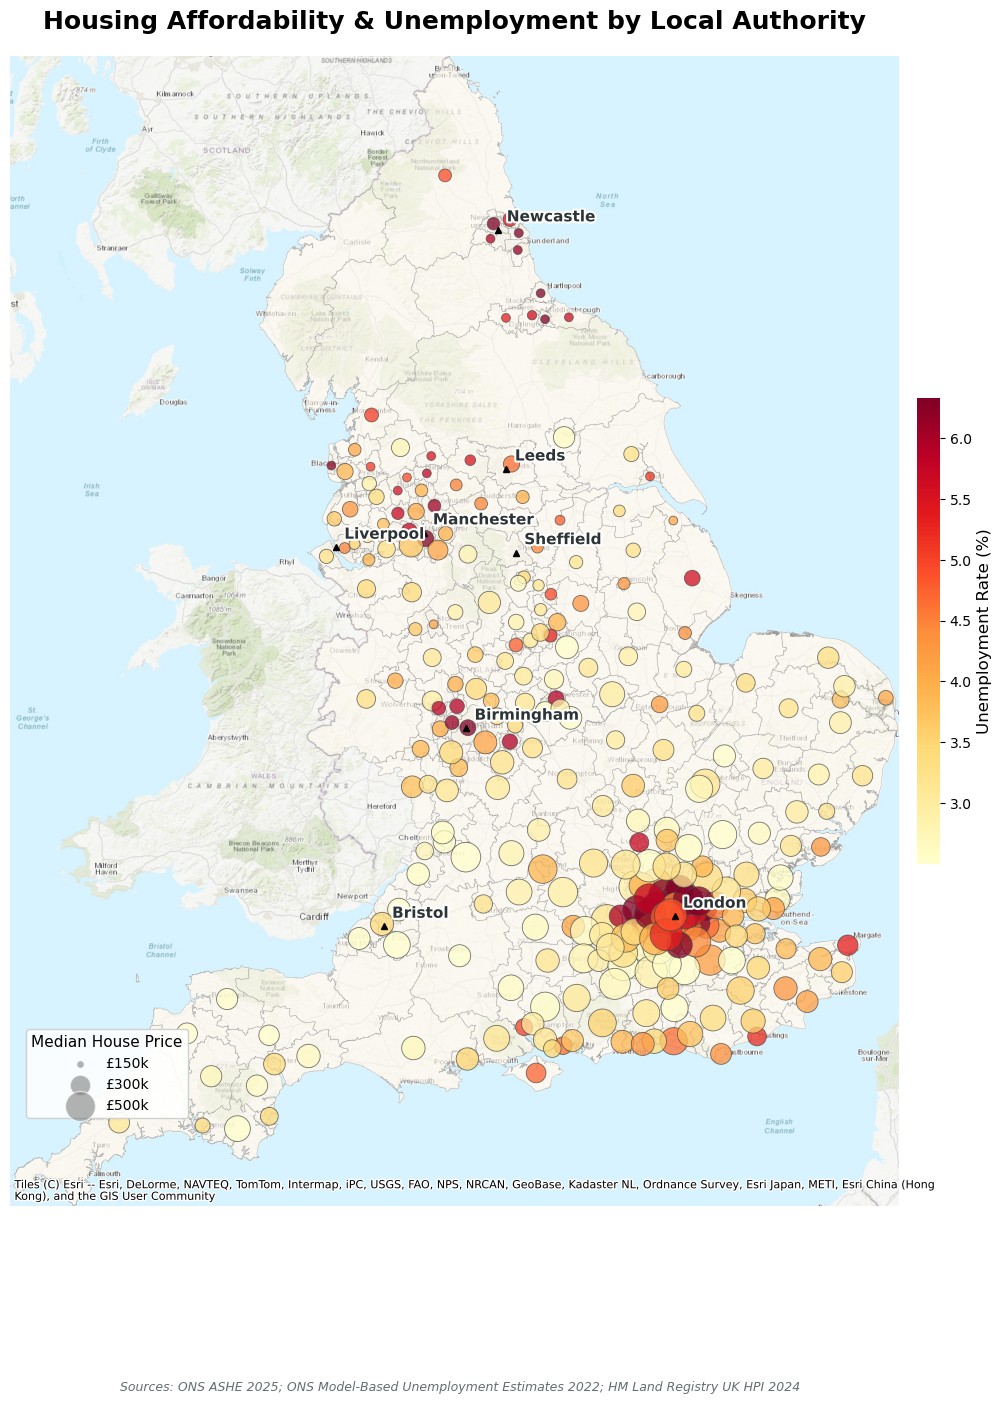

In [4]:
minx, miny, maxx, maxy = final_gdf_3857.total_bounds

fig, ax = plt.subplots(1, 1, figsize=(12, 16), facecolor='white')
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Topo basemap — gives water, terrain, and natural land colour
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTopoMap, alpha=1.0, zoom=8)

# England fill — use a very light warm tint at low alpha so topo shows through
# but England is clearly brighter/warmer than the grey Scotland/Wales on the topo
final_gdf_3857.plot(ax=ax, color='#fffaf0', edgecolor='#999999', linewidth=0.4, alpha=0.6, zorder=2)

# Centroids
centroids = final_gdf_3857.copy()
centroids['geometry'] = centroids.geometry.centroid
centroids = centroids.dropna(subset=['median_house_price', 'unemployment_rate'])

price_min = centroids['median_house_price'].quantile(0.05)
price_max = centroids['median_house_price'].quantile(0.95)
sizes = ((centroids['median_house_price'] - price_min) / (price_max - price_min)).clip(0,1) * 500 + 40

norm = mcolors.Normalize(
    vmin=centroids['unemployment_rate'].quantile(0.05),
    vmax=centroids['unemployment_rate'].quantile(0.95)
)
cmap = mpl.colormaps['YlOrRd']
colors = cmap(norm(centroids['unemployment_rate']))

# Proportional symbols
ax.scatter(
    centroids.geometry.x, centroids.geometry.y,
    s=sizes, c=colors, alpha=0.75,
    edgecolors='#444444', linewidths=0.6, zorder=5
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Unemployment Rate (%)', fontsize=12)
cbar.outline.set_visible(False)

# Size legend
for price, label in [(150000, '£150k'), (300000, '£300k'), (500000, '£500k')]:
    size = ((price - price_min) / (price_max - price_min)) * 500 + 40
    ax.scatter([], [], s=size, c='grey', alpha=0.6, label=label, edgecolors='white')
ax.legend(title='Median House Price', loc='lower left', fontsize=10,
          title_fontsize=11, framealpha=0.9, bbox_to_anchor=(0.01, 0.07))

# City labels
for city, (lon, lat) in major_cities.items():
    pt = gpd.GeoSeries(gpd.points_from_xy([lon], [lat]), crs="EPSG:4326").to_crs(epsg=3857)
    x, y = pt.geometry.x[0], pt.geometry.y[0]
    ax.plot(x, y, 'k^', markersize=5, zorder=10)
    ax.text(x + 8000, y + 8000, city, fontsize=11, fontweight='bold',
            color='#2d3436', zorder=11,
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

ax.set_axis_off()
ax.set_title('Housing Affordability & Unemployment by Local Authority',
             fontsize=18, fontweight='bold', pad=20)

fig.text(0.5, 0.02,
         'Sources: ONS ASHE 2025; ONS Model-Based Unemployment Estimates 2022; HM Land Registry UK HPI 2024',
         ha='center', fontsize=9, color='#636e72', style='italic')

plt.savefig('proportional_symbols.png', dpi=100, bbox_inches=None)
plt.show()

## Geovisualisation and Analysis Rationale (~ 200 words)

The story this dashboard tells is one of spatial divergence: England is not uniformly unequal, and the relationship between earnings, unemployment, and housing costs varies considerably by place. High incomes in London and the South East do not translate into affordability, they drive it in the opposite direction. Conversely, areas of high unemployment in the North and coastal periphery are not necessarily the least affordable. The goal of this geovisualisation is to make that complexity visible and navigable.


This analysis uses a multi-scalar approach combining static choropleth maps with an interactive Panel dashboard, to allow comparative interrogation of three dimensions of spatial inequality: economic capacity (i.e. median income), labour market stress (i.e. unemployment rate) and housing affordability (i.e. price-to-income ratio). The static maps give an immediate national picture, using a quantile classification scheme. This avoids visual distortion from extreme outliers (particularly important given the steep income gradient in London) and concentrates on relative spatial position rather than absolute values. As per established cartographic best practice for web-projected thematic maps, each map is layered with a topographic basemap and a separate label layer to ensure legibility across all colour intensities. This analysis is further enriched by a dynamic variable and year switching interactive dashboard, which facilitates an exploratory pattern discovery process for a complex, multi-variable dataset.

The three-panel choropleth confirms the central divergence: affordability ratios in Greater London and the surrounding Home Counties reach values of 11–28x earnings, while unemployment clusters in the former industrial corridor running from Newcastle through Sheffield to Birmingham, where rates of 5–8% persist well above the national average. Critically, these two geographies do not overlap — Northern authorities combine high unemployment with relatively moderate affordability ratios, while Southern authorities face acute affordability stress despite strong earnings and lower unemployment. This spatial decoupling suggests that housing unaffordability and labour market disadvantage represent distinct, geographically separate dimensions of inequality rather than co-occurring symptoms of the same underlying deprivation.

In [29]:
METRICS = {
    'median_house_price':  dict(label='Median House Price',  unit='£', bokeh_palette=Plasma256),
    'affordability_ratio': dict(label='Affordability Ratio', unit='x', bokeh_palette=Viridis256),
    'median_income':       dict(label='Median Income',       unit='£', bokeh_palette=Plasma256),
    'unemployment_rate':   dict(label='Unemployment Rate',   unit='%', bokeh_palette=Viridis256),
}

RANKS  = ['top', 'bottom']
N_VALS = [5, 10, 15]

years = sorted([int(y) for y in house_final['year'].dropna().unique()], reverse=True)[:5]

# ── Geometry preparation ──────────────────────────────────────────────────────

_base_geo = (
    final_gdf[['local_authority_code', 'local_authority_name', 'geometry',
                'median_income', 'unemployment_rate']]
    .copy()
    .to_crs(epsg=3857)
)
_base_geo['geometry'] = _base_geo['geometry'].simplify(tolerance=1800, preserve_topology=True)

# ── Helper functions ──────────────────────────────────────────────────────────

def get_data(y):
    """Merge house price data for a given year into the base geodataframe."""
    prices = (house_final[house_final['year'].astype(int) == y]
              .set_index('AreaCode')['median_house_price']
              .to_dict())
    m = _base_geo.copy()
    lad_index = final_gdf.set_index('local_authority_code')
    m['median_house_price']  = pd.to_numeric(m['local_authority_code'].map(prices), errors='coerce')
    m['median_income']       = pd.to_numeric(m['local_authority_code'].map(lad_index['median_income']), errors='coerce')
    m['unemployment_rate']   = pd.to_numeric(m['local_authority_code'].map(lad_index['unemployment_rate']), errors='coerce')
    m['affordability_ratio'] = m['median_house_price'] / m['median_income'].replace(0, np.nan)
    return m

def bokeh_palette_to_mpl_cmap(palette):
    """Convert a Bokeh colour palette to a Matplotlib ListedColormap."""
    return mcolors.ListedColormap([mcolors.to_rgba(c) for c in palette])


all_geojson = {}
all_ranges  = {}

for y in years:
    df = get_data(y)
    for m_key in METRICS:
        subset = (df.dropna(subset=[m_key])
                    .cx[-750000:200000, 6420000:7650000]
                  [['local_authority_name', 'local_authority_code', m_key, 'geometry']]
                  .copy())
        key = f"{y}__{m_key}"
        all_geojson[key] = subset.to_json()
        all_ranges[key]  = [float(subset[m_key].min()), float(subset[m_key].max())]

all_bar_images = {}

for y in years:
    df = get_data(y)
    for m_key, cfg in METRICS.items():
        df_v     = df.dropna(subset=[m_key])
        norm     = mcolors.Normalize(vmin=df_v[m_key].min(), vmax=df_v[m_key].max())
        mpl_cmap = bokeh_palette_to_mpl_cmap(cfg['bokeh_palette'])

        for rank in RANKS:
            for n in N_VALS:
                sub    = (df_v.nlargest(n, m_key) if rank == 'top'
                          else df_v.nsmallest(n, m_key)).sort_values(m_key)
                avg    = df_v[m_key].mean()
                vmax   = sub[m_key].max()
                colors = mpl_cmap(norm(sub[m_key].values))

                plt.ioff()
                fig, ax = plt.subplots(figsize=(7, 5), facecolor='#1a1f3a')
                ax.set_facecolor('#0e0f1f')
                ax.barh(sub['local_authority_name'], sub[m_key],
                        color=colors, edgecolor='white', linewidth=0.5)
                ax.set_xlim(0, vmax * 1.35)

                for bar in ax.patches:
                    width = bar.get_width()
                    fmt = f'{width:,.1f}' if cfg['unit'] in ['x', '%'] else f'{width:,.0f}'
                    ax.text(width + (vmax * 0.02), bar.get_y() + bar.get_height() / 2,
                            fmt, va='center', ha='left', color='white',
                            fontsize=9, fontweight='bold')

                ax.set_xlabel(f"Value ({cfg['unit']})", color='#7a7faa', fontsize=9)
                ax.set_title(f"{rank.title()} {n}: {cfg['label']}", color='white', pad=25)
                ax.axvline(avg, color='#f06292', linestyle='--', linewidth=2)
                ax.text(avg, ax.get_ylim()[1] * 1.02,
                        f'Avg: {avg:,.0f}', color='#f06292', ha='center', fontweight='bold')
                ax.tick_params(colors='#7a7faa', labelsize=8)
                fig.subplots_adjust(left=0.35, right=0.88, top=0.85, bottom=0.15)

                buf = io.BytesIO()
                fig.savefig(buf, format='png', dpi=95, bbox_inches='tight',
                            facecolor=fig.get_facecolor())
                plt.close(fig)
                buf.seek(0)
                all_bar_images[f"{y}__{m_key}__{rank}__{n}"] = (
                    base64.b64encode(buf.read()).decode('utf-8')
                )

#  Build  map figure 

INIT_YEAR   = years[0]
INIT_METRIC = 'median_house_price'
INIT_RANK   = 'top'
INIT_N      = 10
init_key    = f"{INIT_YEAR}__{INIT_METRIC}"

src    = GeoJSONDataSource(geojson=all_geojson[init_key])
lo, hi = all_ranges[init_key]
mapper = LinearColorMapper(
    palette=METRICS[INIT_METRIC]['bokeh_palette'],
    low=lo, high=hi, nan_color='#2a2d50'
)

p = figure(
    width=500, height=550,
    x_range=(-750000, 200000), y_range=(6420000, 7650000),
    x_axis_type='mercator', y_axis_type='mercator',
    tools='pan,wheel_zoom,reset',
    title='Spatial Distribution',
    match_aspect=True,
)
p.add_tile(WMTSTileSource(
    url='https://server.arcgisonline.com/ArcGIS/rest/services/'
        'Ocean/World_Ocean_Base/MapServer/tile/{z}/{y}/{x}'
))
patches_r = p.patches(
    xs='xs', ys='ys', source=src,
    fill_color={'field': INIT_METRIC, 'transform': mapper},
    fill_alpha=0.7, line_color='white', line_width=0.4,
)
p.add_tile('CartoDB.PositronOnlyLabels', level='overlay')
p.add_layout(ColorBar(
    color_mapper=mapper,
    ticker=BasicTicker(desired_num_ticks=6),
    formatter=NumeralTickFormatter(format='0,0'),
    label_standoff=12, location=(0, 0),
    background_fill_alpha=0,
    major_label_text_color='white',
    bar_line_color='white',
), 'right')
p.add_tools(HoverTool(
    renderers=[patches_r],
    tooltips=[("Area", "@local_authority_name"),
              ("Value", f"@{INIT_METRIC}{{0,0.00}}")],
))
p.axis.visible          = False
p.grid.grid_line_color  = None
p.background_fill_color = '#1c1e3d'
p.border_fill_color     = '#1c1e3d'
p.title.text_color      = 'white'
p.title.text_font_size  = '13px'

#  Bar chart display div 

init_bar_key = f"{INIT_YEAR}__{INIT_METRIC}__{INIT_RANK}__{INIT_N}"
bar_div = Div(
    text=(f'<img src="data:image/png;base64,{all_bar_images[init_bar_key]}" '
          f'style="width:560px;height:400px;"/>'),
    width=560, height=420,
    styles={'background': '#1a1f3a', 'padding': '10px', 'border-radius': '6px'},
)

#  Widgets 
def titled(title, widget):
    """Wrap a widget with a white HTML title label."""
    return column(
        Div(text=f'<span style="color:white;font-size:12px;">{title}</span>'),
        widget,
        spacing=2,
    )

year_w   = BkSelect(value=str(INIT_YEAR), options=[str(y) for y in years],  width=180)
metric_w = BkSelect(value=INIT_METRIC,    options=list(METRICS.keys()),      width=180)
rank_w   = BkSelect(value=INIT_RANK,      options=['top', 'bottom'],         width=180)
n_w      = BkSelect(value=str(INIT_N),    options=[str(v) for v in N_VALS], width=180)


callback = CustomJS(
    args=dict(
        src=src, mapper=mapper, patches_r=patches_r,
        bar_div=bar_div, title_obj=p.title,
        all_geojson=all_geojson, all_ranges=all_ranges,
        all_bar_images=all_bar_images,
        year_w=year_w, metric_w=metric_w, rank_w=rank_w, n_w=n_w,
        metric_palettes={k: v['bokeh_palette'] for k, v in METRICS.items()},
        fixed_metrics=['unemployment_rate'],
    ),
    code="""
        const y    = year_w.value;
        const m    = metric_w.value;
        const rank = rank_w.value;
        const n    = n_w.value;

        // Update map source and colour mapper
        const map_key  = y + '__' + m;
        src.geojson    = all_geojson[map_key];
        src.change.emit();
        const rng      = all_ranges[map_key];
        mapper.low     = rng[0];
        mapper.high    = rng[1];
        mapper.palette = metric_palettes[m];

        // Update fill colour field
        patches_r.glyph.fill_color = {field: m, transform: mapper};

        // Update map title
        title_obj.text = 'Spatial Distribution' +
                         (fixed_metrics.includes(m) ? ' (data fixed at 2022)' : '');

        // Swap bar chart image
        bar_div.text = '<img src="data:image/png;base64,' +
                       all_bar_images[y + '__' + m + '__' + rank + '__' + n] +
                       '" style="width:560px;height:400px;"/>';
    """
)

for w in [year_w, metric_w, rank_w, n_w]:
    w.js_on_change('value', callback)

# Assemble layout 

header = Div(
    text=('<div style="background:#1a2a6c;padding:15px;border-radius:5px;width:1200px;">'
          '<h2 style="color:white;margin:0;font-family:sans-serif;">'
          '🇬🇧 UK Housing &amp; Labour Market Analytics</h2></div>'),
    width=1250,
)
controls = column(
    Div(text='<h3 style="color:white;margin:0 0 10px 0;font-family:sans-serif;">Controls</h3>'),
    titled('Analysis Year',   year_w),
    titled('Metric',          metric_w),
    titled('Ranking',         rank_w),
    titled('Number of Areas', n_w),
    styles={'background': '#1a1f3a', 'padding': '15px', 'border-radius': '6px'},
    width=220,
)
full_layout = column(
    header,
    row(controls, p, bar_div, spacing=20),
    styles={'background': '#0e0f1f', 'padding': '20px'},
)


WIDGET_STYLE = """
    .bk-input {
        background: #0e0f1f !important;
        color: white !important;
        border: 1px solid #3a3f6e !important;
        border-radius: 4px !important;
    }
    .bk-input-group label, .bk-widget-form-label, label {
        color: white !important;
        font-size: 12px !important;
    }
"""

html_out = file_html(full_layout, resources=INLINE, title='Assignment 2 Dashboard')
html_out = html_out.replace('</head>', f'<style>{WIDGET_STYLE}</style></head>')

with open('ENVS456/dashboard.html', 'w') as f:
    f.write(html_out)

IFrame('ENVS456/dashboard.html', width=1500, height=700)

## Interactivity and design choices (~ 200 words)

This dashboard leverages a reactive functional architecture through the panel.depends framework to synchronize spatial and statistical views, ensuring that adjustments to the year, metric, or ranking widgets trigger immediate, cohesive updates across the entire interface. The design prioritizes a modern dark-mode aesthetic to reduce eye strain and maximize the contrast of perceptually uniform colormaps like Plasma and Viridis, which intuitively guide the user toward high-value data points. A critical design choice was the implementation of a layered cartographic stack: by using an Esri Ocean base layer, the map provides immediate geographic grounding through natural blue water, while a high-level CartoDB label overlay keeps city names legible on top of semi-transparent data polygons. This visual hierarchy is further supported by a distribution chart featuring a dynamic national average line, which serves as a vital benchmark for distinguishing localized outliers from broader national trends. By balancing high-density information with clean, grid-free visuals, the dashboard transforms raw housing and labor market data into an accessible, interactive narrative.

## Conclusion (~ 100 words)

This analysis reveals a persistent and geographically entrenched pattern of spatial inequality across England. High earnings in London and the South East do not mitigate housing unaffordability, they actively drive it, producing some of the highest price-to-income ratios in the country. Conversely, unemployment remains concentrated in former industrial areas of the North and coastal periphery, where structural economic disadvantage has proved resistant to national recovery cycles. The interactive dashboard makes these divergent trajectories visible across a 5 year span, enabling users to interrogate the uneven geography of opportunity at local authority level. Together, the evidence underscores that housing and labour market inequalities in England are not incidental but spatially reinforced and self-perpetuating.

**Total word count prose text: 1,235**

## References

Beatty, C. and Fothergill, S. (2016) The Uneven Impact of Welfare Reform. Sheffield Hallam University Centre for Regional Economic and Social Research. Available at: https://www4.shu.ac.uk/research/cresr/sites/shu.ac.uk/files/welfare-reform-2016.pdf

ONS (2024) Annual Survey of Hours and Earnings (ASHE): Table 8.7a – Annual Pay (Gross) by Home Geography, 2025 Provisional. Office for National Statistics, published via NOMIS. Available at: https://www.nomisweb.co.uk

ONS (2025) Model-Based Unemployment Estimates, August 2022. Office for National Statistics. Available at: https://www.ons.gov.uk/employmentandlabourmarket/peoplenotinwork/unemployment

Rey, S.J., Arribas-Bel, D. and Wolf, L.J. (2020) Geographic Data Science with Python. Available at: https://geographicdata.science/book
Szumilo, N. (2019) 'The geography of housing affordability in England', Journal of European Real Estate Research, 12(2), pp. 149–167. https://doi.org/10.1108/JERER-02-2018-0008

UK House Price Index / HM Land Registry (2025) UK HPI Full File – Price Paid Data, 2024. Available at: https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-january-2024

Barker, K. (2004) Review of Housing Supply: Delivering Stability – Securing our Future Housing Needs. HM Treasury. Available at: https://webarchive.nationalarchives.gov.uk/ukgwa/20140402141250/http://www.hm-treasury.gov.uk/consult_barker_index.htm


McCann, P. (2016) The UK Regional–National Economic Problem: Geography, Globalisation and Governance. Routledge, London.


Tunstall, R., Bevan, M., Bradshaw, J., Croucher, K., Duffy, S., Hunter, C., Jones, A., Kelley, N., Pleace, N., Stephens, M. and Wilcox, S. (2013) The Links Between Housing and Poverty in the UK. Joseph Rowntree Foundation. Available at: https://www.jrf.org.uk/report/links-between-housing-and-poverty

## Generative AI Use Statement (e.g. ChatGPT, Copilot, Gemini, Claude, or alike systems)

I declare that this assignment reflects my own work and I remain fully responsible for the content submitted.

### Disclosure of AI Use

**AI use level (Add "x" where relevant):**  
- [ ] No AI used.
- [ ] Minor support for coding (e.g. specific functions, or errors handling).
- [x] Minor support for checking the presence of typos in the text.
- [x] Moderate support in reviewing/improving code.
- [ ] Substantial support in generating code.
- [ ] Substantial support in generating prose text and content.
      
### Acknowledgement
I understand that undeclared or misleading use of generative AI may be treated as a breach of academic integrity requirements.